In [2]:
## Load full joint library + precomputed gradient-corrected deepSHAP attributions.
import os, sys, numpy as np, pandas as pd

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap, ENHANCER_LEN

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n_full][keep]

print(f'{len(df)} seqs   X={tuple(em.X.shape)}')


EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs   X=(56975, 4, 281)


SEL_IDX: [39573, 42132, 47017, 38571, 56772, 19345, 45516, 45860]


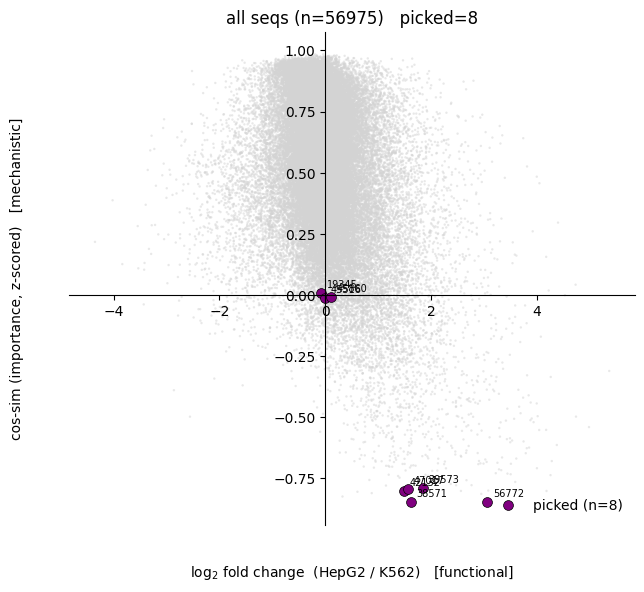

In [3]:
## 2d (functional, mechanistic) space — only the picked target_loci seqs labeled.
##   x = log2 fold change HepG2 / K562 (functional)
##   y = cos-sim of importance maps z-scored (mechanistic; low = divergent)
import matplotlib.pyplot as plt, pickle

PICKS_PKL = os.path.join(REPO, 'virtual_perturbations/diff_call/results/target_loci_library.pkl')
with open(PICKS_PKL, 'rb') as f:
    picks = pickle.load(f)
SEL_IDX = picks['df']['seq_idx'].astype(int).tolist()
print('SEL_IDX:', SEL_IDX)

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values
fin    = np.isfinite(cossim) & np.isfinite(lfc)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(lfc[fin], cossim[fin], s=3, c='lightgray',
           alpha=0.5, edgecolors='none', rasterized=True)
ax.scatter(lfc[SEL_IDX], cossim[SEL_IDX], s=50, c='purple',
           edgecolors='k', lw=0.5, label=f'picked (n={len(SEL_IDX)})')
for i in SEL_IDX:
    ax.annotate(str(i), (lfc[i], cossim[i]), fontsize=7,
                xytext=(4, 4), textcoords='offset points')

# Spines through origin, ticks on the crossing axes.
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
# Axis labels pinned to the figure border (not the inner spine).
ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
ax.xaxis.set_label_coords(0.5, -0.08)
ax.yaxis.set_label_coords(-0.08, 0.5)
ax.set_title(f'all seqs (n={fin.sum()})   picked={len(SEL_IDX)}')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout(); plt.show()


In [4]:
## Load TF-MoDISco results for the full ~56K library (run separately via run_modisco_full.sbatch).
import h5py
from types import SimpleNamespace

ENH = ENHANCER_LEN
OUT_DIR = os.path.join(REPO, 'genomic_targets/data/modisco')
HP_TAG = f'full56k_enh{ENH}_default'

def load_patterns(h5_path, group):
    out = []
    with h5py.File(h5_path, 'r') as f:
        if group not in f: return []
        names = sorted(f[group].keys(), key=lambda s: int(s.split('_')[-1]))
        for nm in names:
            g = f[group][nm]
            seqlets = [SimpleNamespace(example_idx=int(e))
                       for e in g['seqlets']['example_idx'][...]]
            out.append(SimpleNamespace(
                contrib_scores=g['contrib_scores'][...],
                seqlets=seqlets,
            ))
    return out

results_full = {}
for ct in CT:
    h5 = os.path.join(OUT_DIR, f'{ct}_{HP_TAG}.h5')
    pos = load_patterns(h5, 'pos_patterns')
    neg = load_patterns(h5, 'neg_patterns')
    results_full[ct] = (pos, neg, h5)
    print(f'{ct:5s}  pos={len(pos)} neg={len(neg)}  -> {os.path.basename(h5)}')


K562   pos=29 neg=11  -> K562_full56k_enh230_default.h5
HepG2  pos=31 neg=4  -> HepG2_full56k_enh230_default.h5


In [5]:
## Annotate motif occurrences with finemo_gpu — per cell type, against its own modisco h5.
##   inputs:  enh-region OHE + hypothetical attributions + per-seq genomic coords (NarrowPeak)
##   outputs: data/motif/{ct}/  (regions.npz, hits.tsv, ...)
##   skipped per-ct if hits.tsv already exists.
import subprocess

FINEMO    = os.path.join(REPO, '.venv/bin/finemo')
MOTIF_DIR = os.path.join(REPO, 'genomic_targets/data/motif')
PEAKS_BED = os.path.join(MOTIF_DIR, 'peaks.narrowPeak')
os.makedirs(MOTIF_DIR, exist_ok=True)

# reusable peaks file: ENCODE NarrowPeak (10 cols, summit offset = ENH//2),
# one row per seq, same order as em.X. Synthetic seqs (no genomic origin) get
# chrom='synthetic' / start=0 so row order is preserved.
if not os.path.exists(PEAKS_BED):
    starts = df['start_hg38'].fillna(0).astype(int)
    chroms = df['chr_hg38'].fillna('synthetic')
    bed = pd.DataFrame({
        'chrom':   chroms,
        'start':   starts,
        'end':     starts + ENH,
        'name':    df['name'],
        'score':   0,
        'strand':  '.',
        'signal':  0.0,
        'pval':   -1.0,
        'qval':   -1.0,
        'summit':  ENH // 2,
    })
    bed.to_csv(PEAKS_BED, sep='\t', header=False, index=False)
    print(f'wrote {PEAKS_BED}  ({len(bed)} rows, '
          f'{(chroms == "synthetic").sum()} synthetic)')

ohe_enh = em.X.numpy()[:, :, :ENH].astype(np.float32)

for ct in CT:
    ct_dir = os.path.join(MOTIF_DIR, ct)
    hits_tsv = os.path.join(ct_dir, 'hits.tsv')
    if os.path.exists(hits_tsv):
        print(f'{ct} -> {ct_dir} (cached, skipped)')
        continue

    os.makedirs(ct_dir, exist_ok=True)
    seq_npy = os.path.join(ct_dir, 'sequences.npy')
    hyp_npy = os.path.join(ct_dir, 'hyp_attrs.npy')
    regions = os.path.join(ct_dir, 'regions.npz')
    np.save(seq_npy, ohe_enh)
    np.save(hyp_npy, em.attr_hyp[ct][:, :, :ENH].astype(np.float32))

    subprocess.run([FINEMO, 'extract-regions-modisco-fmt',
                    '-s', seq_npy, '-a', hyp_npy, '-p', PEAKS_BED,
                    '-o', regions, '-w', str(ENH)],
                   check=True)
    subprocess.run([FINEMO, 'call-hits',
                    '-r', regions, '-m', results_full[ct][2], '-o', ct_dir],
                   check=True)
    print(f'{ct} -> {ct_dir}')


K562 -> /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/motif/K562 (cached, skipped)
HepG2 -> /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/motif/HepG2 (cached, skipped)


[4/8]  idx=38571   name=HepG2_DNasePeakNoPromoter61479


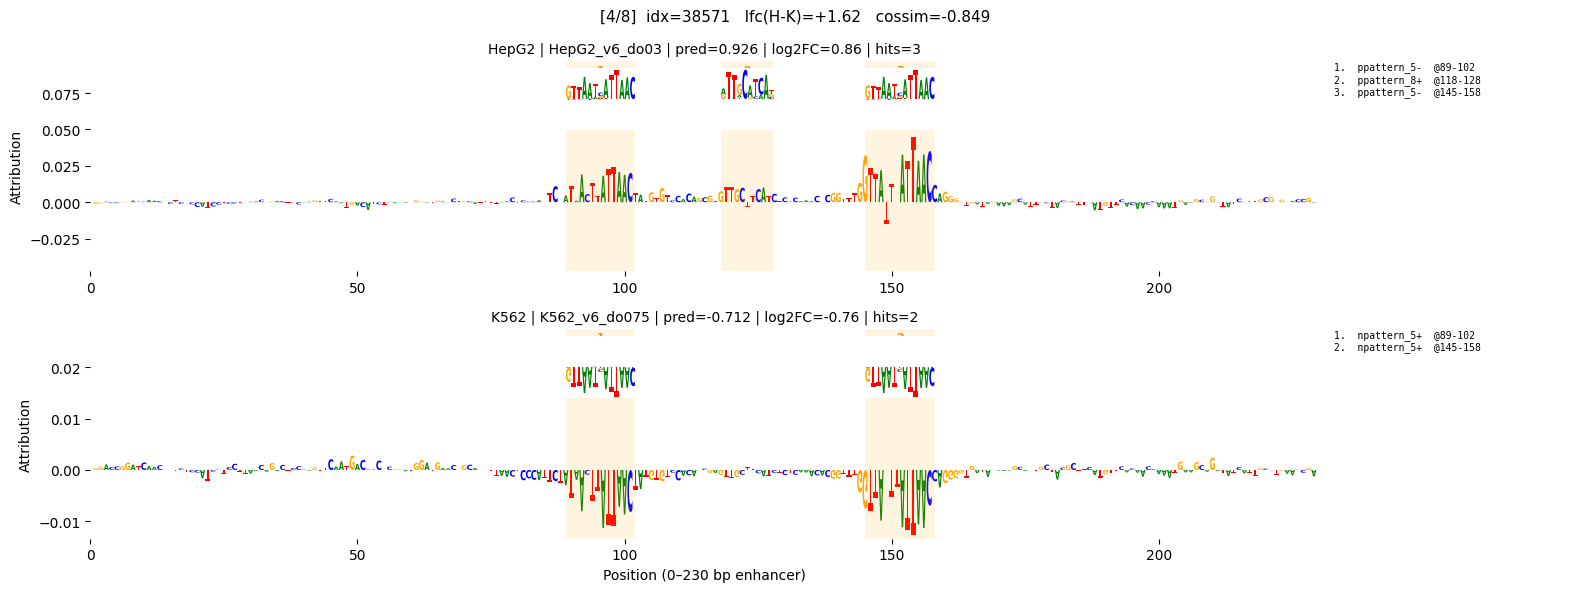

In [23]:
## Cycle through SEL_IDX -> per-ct attribution logo with finemo hits annotated as
## small inset CWM logos (trimmed at finemo's default 0.3 threshold) above each hit.
## Hits are numbered; legend printed beside the plot to avoid overlapping labels.
import eigen_steering as es
es._load_heavy_deps()
fast_logo = es.fast_logo

SEL_I = 3  # <-- 0..len(SEL_IDX)-1, picks SEL_IDX[SEL_I]
ORDER = ['HepG2', 'K562']
ENH = ENHANCER_LEN  # 230
TRIM_THR = 0.3      # finemo --cwm-trim-threshold default

XX   = SEL_IDX[SEL_I]
name = df['name'].iloc[XX]
print(f'[{SEL_I+1}/{len(SEL_IDX)}]  idx={XX}   name={name}')

peak_start = int(df['start_hg38'].fillna(0).iloc[XX])

hits_by_ct = {}
for ct in CT:
    h = pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{ct}/hits.tsv'),
                    sep='\t', usecols=['start','end','motif_name','strand','peak_id'])
    h = h[h['peak_id'] == XX].copy().sort_values('start').reset_index(drop=True)
    h['x0'] = h['start'].astype(int) - peak_start
    h['x1'] = h['end'].astype(int)   - peak_start
    hits_by_ct[ct] = h

def get_pattern(ct, motif_name):
    grp, idx = motif_name.split('.')
    i = int(idx.split('_')[-1])
    return (results_full[ct][0] if grp == 'pos_patterns' else results_full[ct][1])[i].contrib_scores

def trim_cwm(cwm, thr=TRIM_THR):
    imp = np.abs(cwm).sum(axis=1)
    on = imp > thr * imp.max()
    if not on.any(): return cwm
    s, e = on.argmax(), len(on) - on[::-1].argmax()
    return cwm[s:e]

fig, axes = plt.subplots(len(ORDER), 2, figsize=(16, 3.0 * len(ORDER)),
                         gridspec_kw={'width_ratios': [5, 1]})
for (ax, ax_legend), ct in zip(axes, ORDER):
    a = em.attr[ct][XX, :, :ENH]
    yabs = abs(a).max() * 1.05
    fast_logo(a, ax=ax, ylim=(-yabs, yabs))

    for k, h in hits_by_ct[ct].iterrows():
        ax.axvspan(h['x0'], h['x1'], color='orange', alpha=0.12, lw=0)
        cwm = get_pattern(ct, h['motif_name'])
        cwm = trim_cwm(cwm)
        if h['strand'] == '-': cwm = cwm[::-1, ::-1]
        w_data = max(h['x1'] - h['x0'], 1)
        ins = ax.inset_axes([h['x0'], yabs * 1.05, w_data, yabs * 0.9],
                            transform=ax.transData)
        cwm_yabs = max(abs(cwm).max() * 1.05, 1e-6)
        fast_logo(cwm.T, ax=ins, ylim=(-cwm_yabs, cwm_yabs))
        ins.set_xticks([]); ins.set_yticks([])
        for sp in ins.spines.values(): sp.set_visible(False)
        # numeric label only — full motif name goes in the side legend
        ax.text((h['x0'] + h['x1']) / 2, yabs * 2.0, str(k + 1),
                ha='center', va='top', fontsize=8, color='darkorange', fontweight='bold')

    parts = [ct, em.model_names[ct]]
    if ct in em.predictions: parts.append(f'pred={em.predictions[ct][XX]:.3f}')
    parts.append(f'log2FC={df[f"{ct}_log2FC"].iloc[XX]:.2f}')
    parts.append(f'hits={len(hits_by_ct[ct])}')
    ax.set_title(' | '.join(parts), fontsize=10)
    ax.set_ylabel('Attribution')
    ax.set_xlim(0, ENH)
    ax.set_ylim(-yabs, yabs * 2.05)
    for sp in ax.spines.values(): sp.set_visible(False)

    # side legend: numeric key -> motif name
    ax_legend.axis('off')
    lines = [f"{k+1}.  {h['motif_name'].replace('pos_patterns.','p').replace('neg_patterns.','n')}{h['strand']}  @{h['x0']}-{h['x1']}"
             for k, h in hits_by_ct[ct].iterrows()]
    ax_legend.text(0, 1, '\n'.join(lines), va='top', ha='left', fontsize=7,
                   family='monospace')

axes[-1, 0].set_xlabel(f'Position (0–{ENH} bp enhancer)')
fig.suptitle(f'[{SEL_I+1}/{len(SEL_IDX)}]  idx={XX}   '
             f'lfc(H-K)={lfc[XX]:+.2f}   cossim={cossim[XX]:+.3f}',
             fontsize=11)
plt.tight_layout(); plt.show()


/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


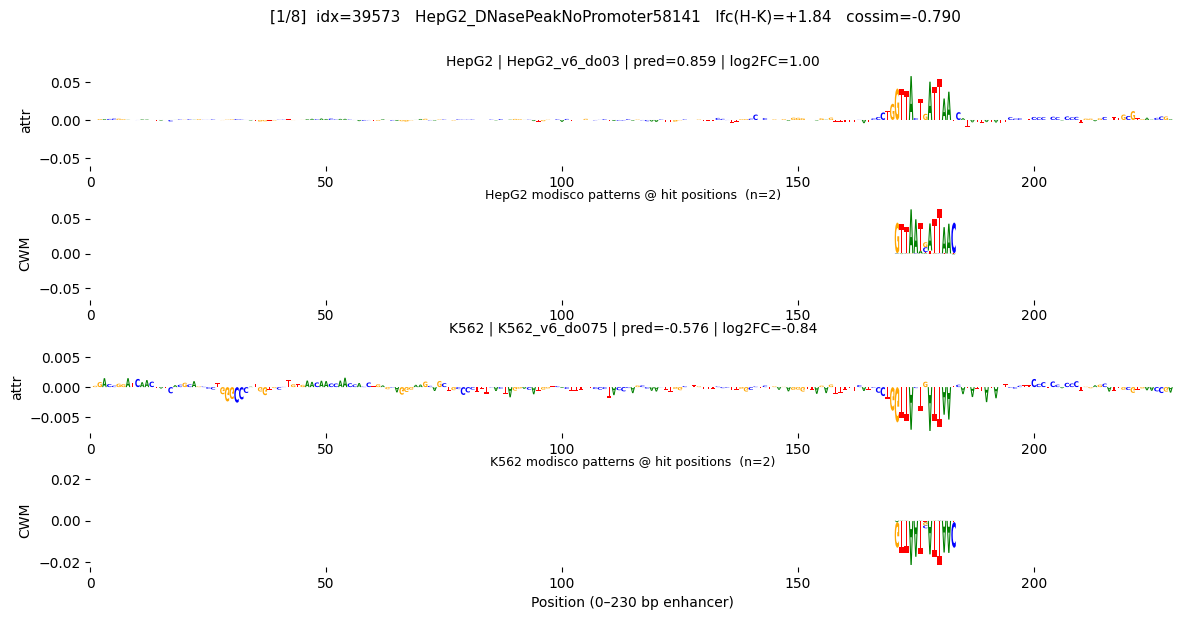

/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


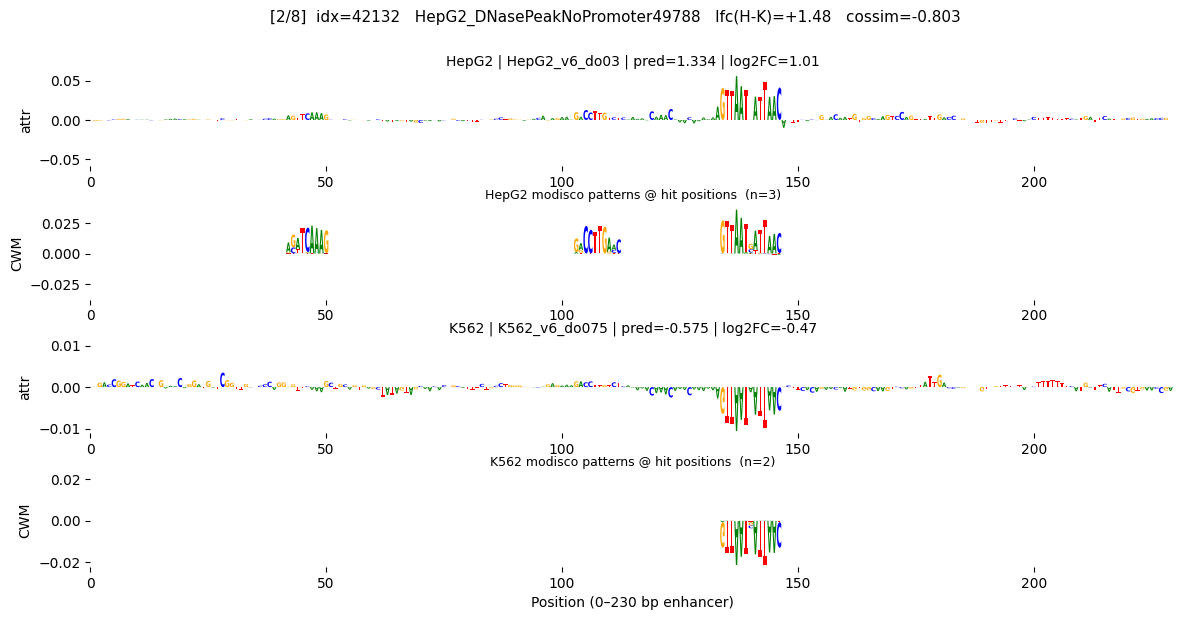

/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


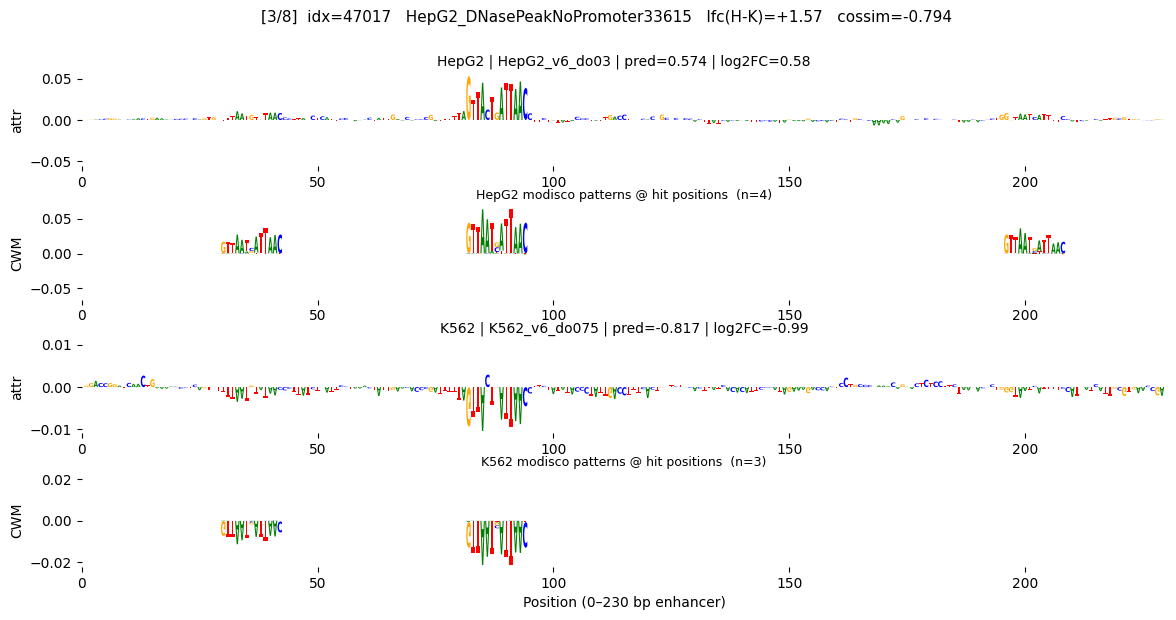

/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


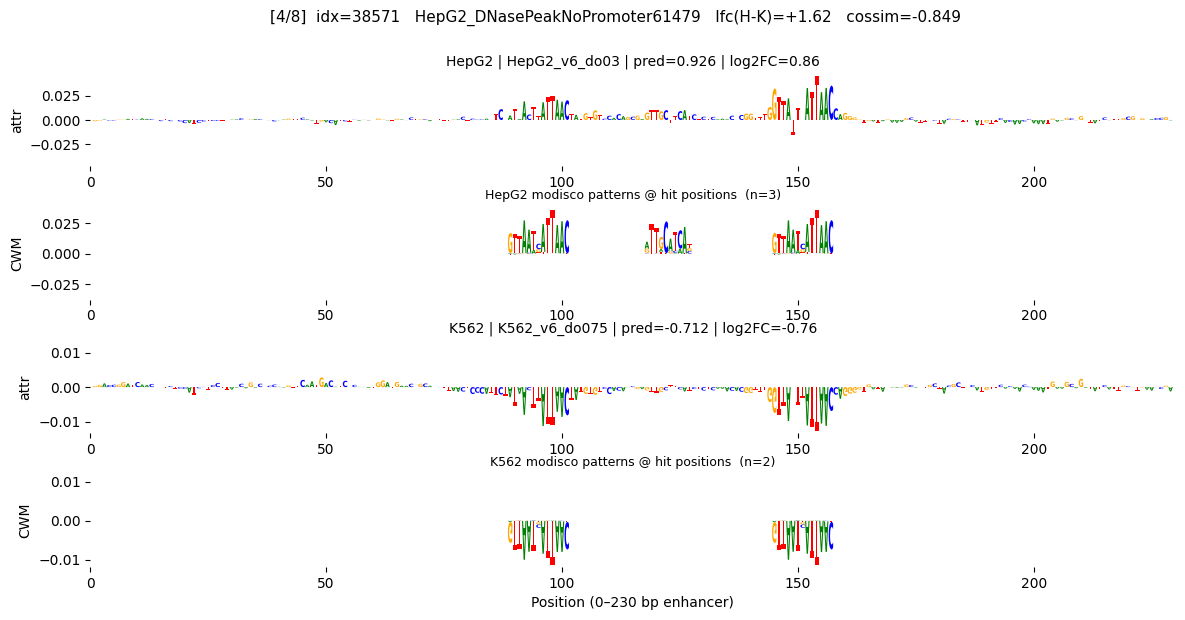

/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


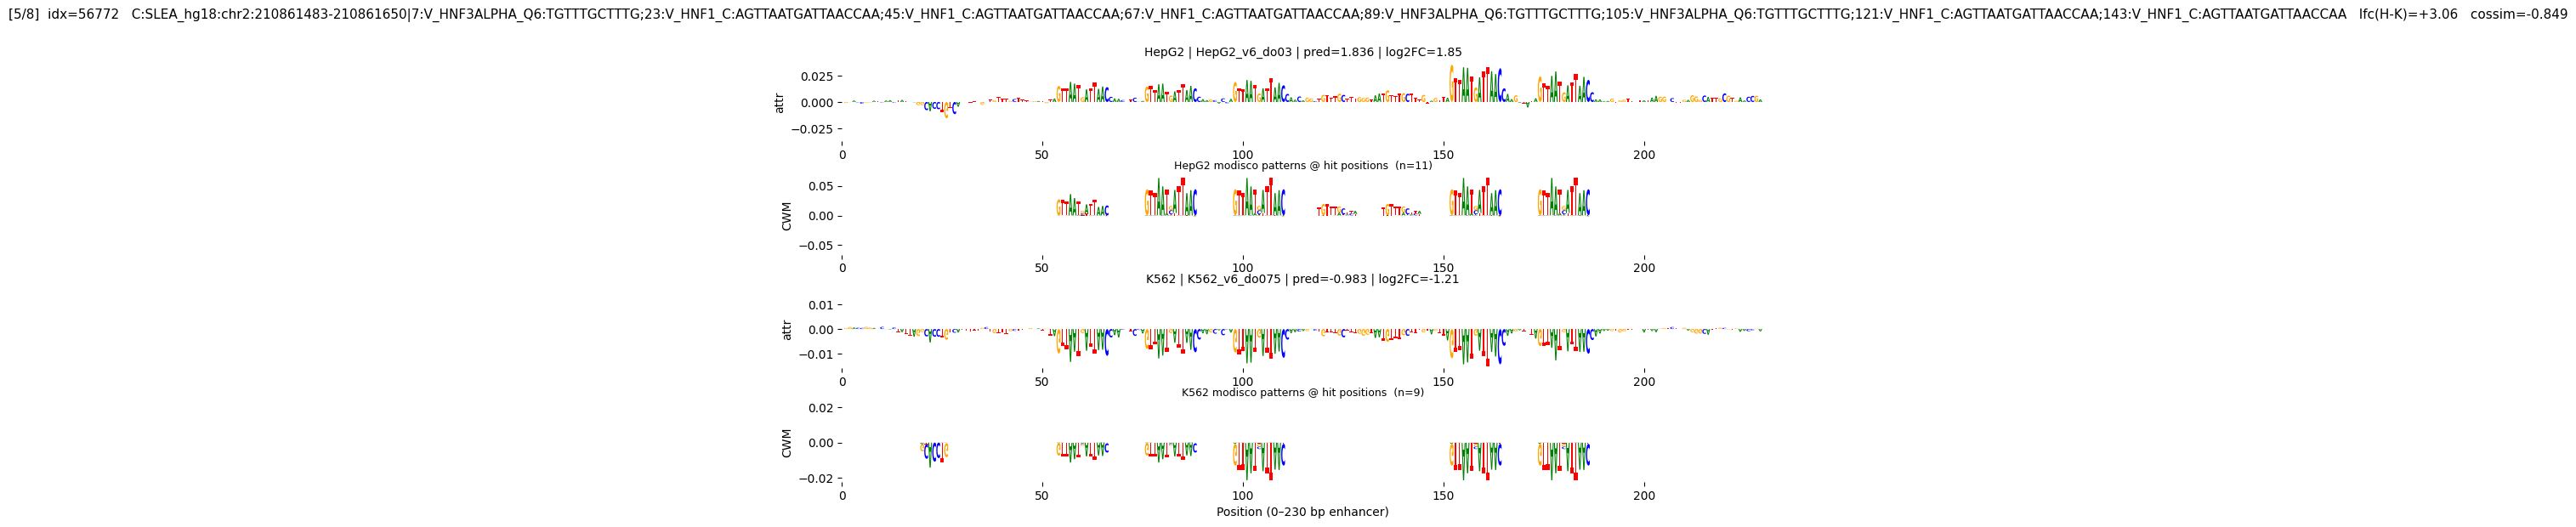

/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


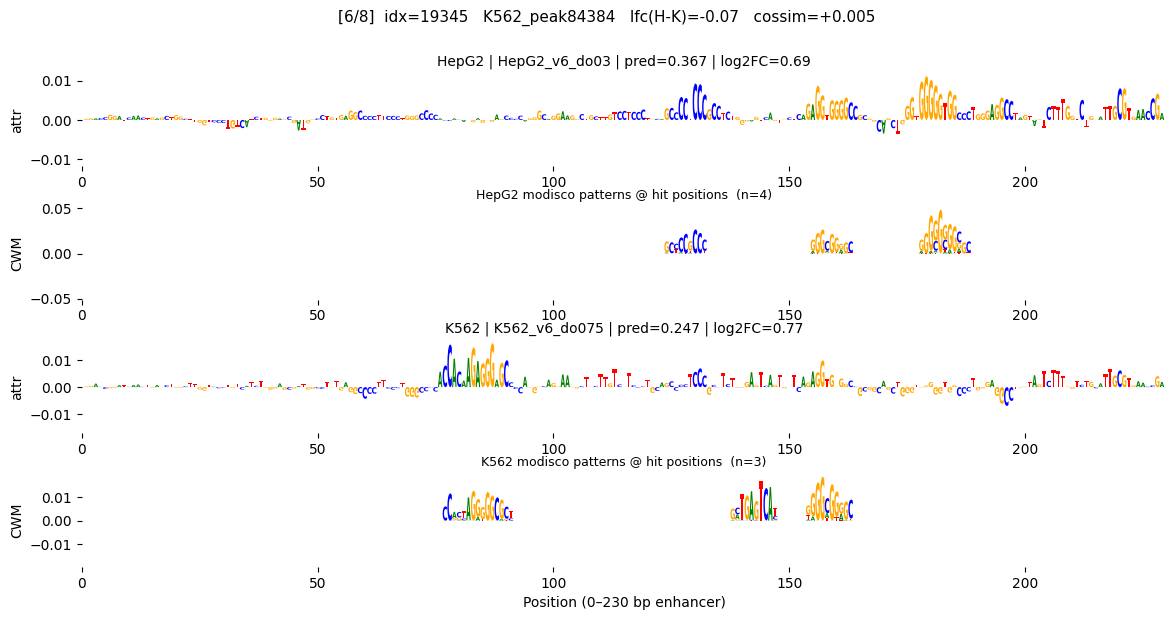

/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


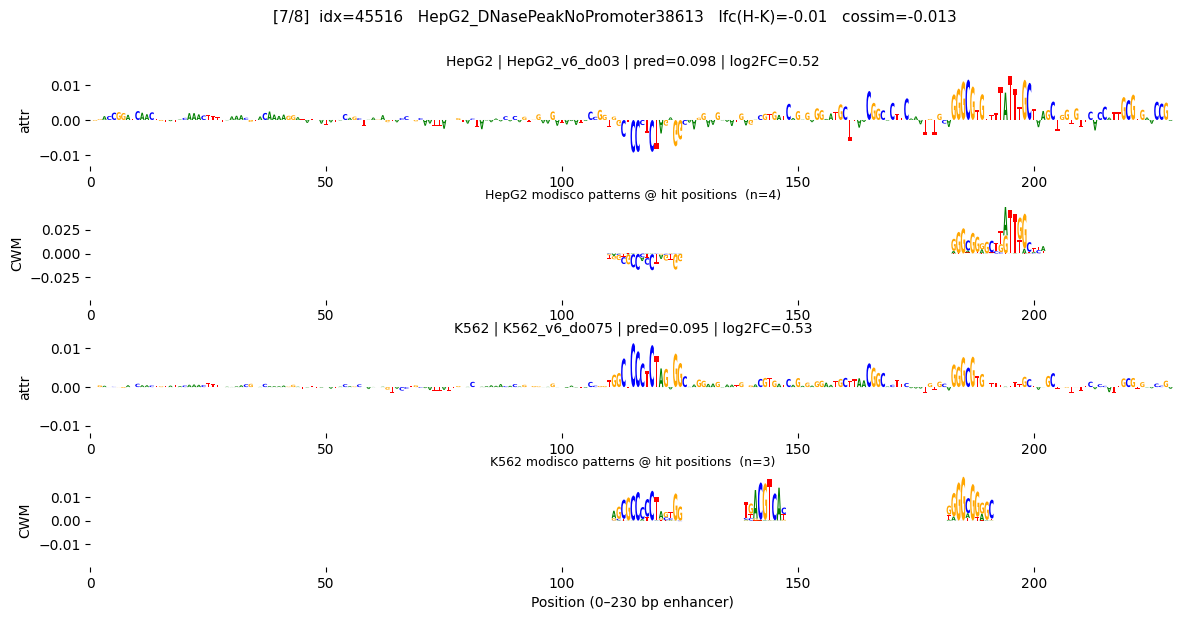

/tmp/slurm_tmp/2013111/ipykernel_1292557/1108593764.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


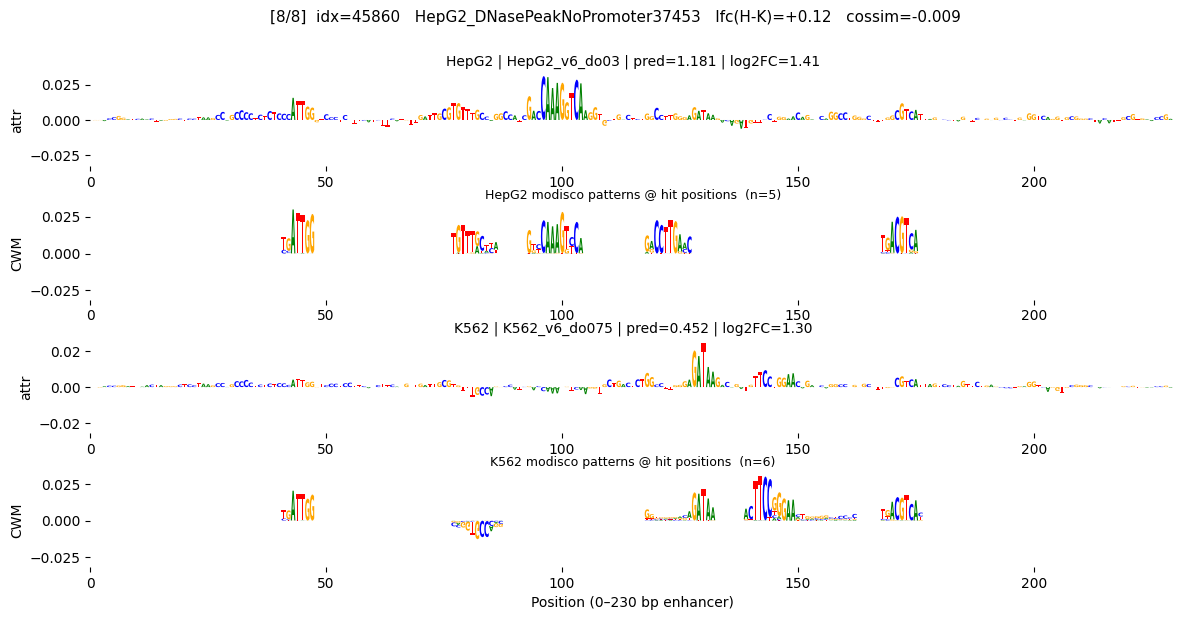

In [24]:
## Per-ct seq attr + pattern track (below) for ALL picks. Each ct's hits + CWMs go
## only on that ct's row — no cross-ct overlay. CWMs trimmed at finemo default (0.3),
## placed on a (4, ENH) zero array at the trimmed [x0, x1] hit window.
for sel_i, xx in enumerate(SEL_IDX):
    name_i       = df['name'].iloc[xx]
    peak_start_i = int(df['start_hg38'].fillna(0).iloc[xx])
    fig, axes = plt.subplots(2 * len(ORDER), 1, figsize=(14, 1.6 * 2 * len(ORDER)),
                             gridspec_kw={'hspace': 0.45})
    for ci, ct in enumerate(ORDER):
        ax_seq, ax_pat = axes[2 * ci], axes[2 * ci + 1]

        a = em.attr[ct][xx, :, :ENH]
        yabs_s = abs(a).max() * 1.05
        fast_logo(a, ax=ax_seq, ylim=(-yabs_s, yabs_s))
        parts = [ct, em.model_names[ct]]
        if ct in em.predictions: parts.append(f'pred={em.predictions[ct][xx]:.3f}')
        parts.append(f'log2FC={df[f"{ct}_log2FC"].iloc[xx]:.2f}')
        ax_seq.set_title(' | '.join(parts), fontsize=10)
        ax_seq.set_ylabel('attr'); ax_seq.set_xlim(0, ENH)

        h = pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{ct}/hits.tsv'),
                        sep='\t', usecols=['start','end','motif_name','strand','peak_id'])
        h = h[h['peak_id'] == xx].copy()
        h['x0'] = h['start'].astype(int) - peak_start_i
        h['x1'] = h['end'].astype(int)   - peak_start_i

        track = np.zeros((4, ENH), dtype=np.float32)
        for _, hit in h.iterrows():
            cwm = get_pattern(ct, hit['motif_name'])
            cwm = trim_cwm(cwm, TRIM_THR)
            if hit['strand'] == '-': cwm = cwm[::-1, ::-1]
            L = cwm.shape[0]
            x0 = max(0, hit['x0']); x1 = min(ENH, hit['x0'] + L)
            track[:, x0:x1] += cwm[(x0 - hit['x0']):(x1 - hit['x0'])].T
        yabs_p = max(abs(track).max() * 1.05, 1e-6)
        fast_logo(track, ax=ax_pat, ylim=(-yabs_p, yabs_p))
        ax_pat.set_title(f'{ct} modisco patterns @ hit positions  (n={len(h)})', fontsize=9)
        ax_pat.set_ylabel('CWM'); ax_pat.set_xlim(0, ENH)

        for sp in ax_seq.spines.values(): sp.set_visible(False)
        for sp in ax_pat.spines.values(): sp.set_visible(False)

    axes[-1].set_xlabel(f'Position (0–{ENH} bp enhancer)')
    fig.suptitle(f'[{sel_i+1}/{len(SEL_IDX)}]  idx={xx}   {name_i}   '
                 f'lfc(H-K)={lfc[xx]:+.2f}   cossim={cossim[xx]:+.3f}', fontsize=11)
    plt.tight_layout(); plt.show()


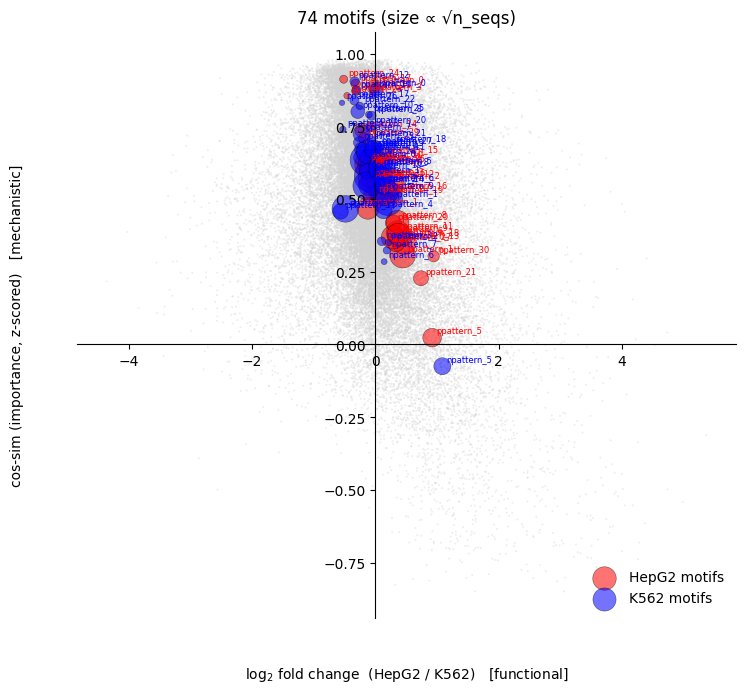

In [25]:
## All discovered motifs on the (functional, mechanistic) space — one marker per motif at
## the centroid of seqs containing it. Marker size ∝ hit-seq count. Color = source ct.
all_hits = {ct: pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{ct}/hits.tsv'),
                            sep='\t', usecols=['motif_name','peak_id'])
            for ct in CT}

rows = []
for ct, h in all_hits.items():
    for motif, g in h.groupby('motif_name'):
        idx = g['peak_id'].unique()
        rows.append(dict(ct=ct, motif=motif, n=len(idx),
                         lfc=lfc[idx].mean(), cossim=cossim[idx].mean()))
M = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(lfc[fin], cossim[fin], s=2, c='lightgray', alpha=0.4, edgecolors='none', rasterized=True)
for ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = M[M['ct'] == ct]
    ax.scatter(sub['lfc'], sub['cossim'], s=np.sqrt(sub['n']) * 4,
               c=color, alpha=0.55, edgecolors='k', lw=0.4, label=f'{ct} motifs')
    for _, r in sub.iterrows():
        short = r['motif'].replace('pos_patterns.', 'p').replace('neg_patterns.', 'n')
        ax.annotate(short, (r['lfc'], r['cossim']), fontsize=6,
                    xytext=(3, 3), textcoords='offset points', color=color)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
ax.xaxis.set_label_coords(0.5, -0.08); ax.yaxis.set_label_coords(-0.08, 0.5)
ax.set_title(f'{len(M)} motifs (size ∝ √n_seqs)')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout(); plt.show()


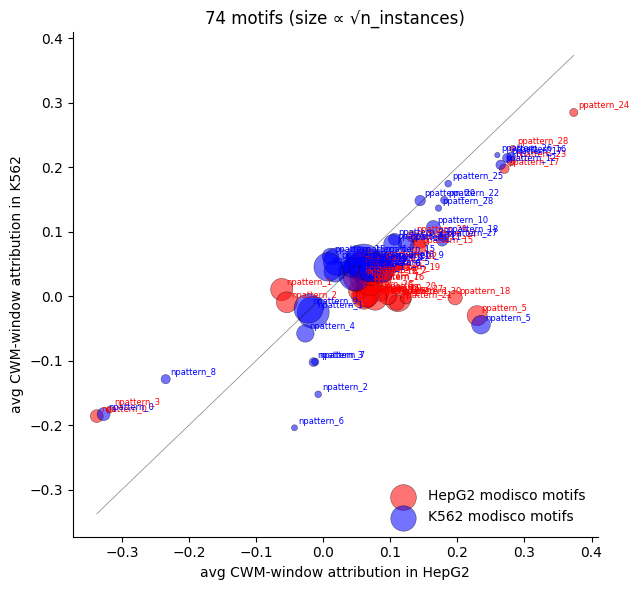

In [26]:
## Per-motif average CWM score in HepG2 vs K562.
##   For each motif (from each ct's modisco), find its instances in that ct's hits.tsv.
##   At each instance window, integrate the attribution in BOTH cts (sum |attr| over
##   the trimmed [x0,x1] window). Average across instances -> (H_score, K_score).
##   Color = source ct of the motif (which modisco run discovered it).
peak_starts = df['start_hg38'].fillna(0).astype(int).values

rows = []
for src_ct in CT:
    h = pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{src_ct}/hits.tsv'),
                    sep='\t', usecols=['start','end','motif_name','peak_id'])
    h['x0'] = h['start'].astype(int) - peak_starts[h['peak_id'].values]
    h['x1'] = h['end'].astype(int)   - peak_starts[h['peak_id'].values]
    for motif, g in h.groupby('motif_name'):
        ig = g[(g['x0'] >= 0) & (g['x1'] <= ENH)]
        if len(ig) == 0: continue
        scores = {ct: [] for ct in CT}
        for _, hit in ig.iterrows():
            pid = int(hit['peak_id']); x0, x1 = int(hit['x0']), int(hit['x1'])
            for ct in CT:
                scores[ct].append(em.attr[ct][pid, :, x0:x1].sum())
        rows.append(dict(src_ct=src_ct, motif=motif, n=len(ig),
                         H=np.mean(scores['HepG2']), K=np.mean(scores['K562'])))
M = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.5, 6))
for src_ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = M[M['src_ct'] == src_ct]
    ax.scatter(sub['H'], sub['K'], s=np.sqrt(sub['n']) * 4,
               c=color, alpha=0.55, edgecolors='k', lw=0.4,
               label=f'{src_ct} modisco motifs')
    for _, r in sub.iterrows():
        short = r['motif'].replace('pos_patterns.', 'p').replace('neg_patterns.', 'n')
        ax.annotate(short, (r['H'], r['K']), fontsize=6,
                    xytext=(3, 3), textcoords='offset points', color=color)

lims = [min(M['H'].min(), M['K'].min()), max(M['H'].max(), M['K'].max())]
ax.plot(lims, lims, 'k-', lw=0.5, alpha=0.5)
ax.set_xlabel('avg CWM-window attribution in HepG2')
ax.set_ylabel('avg CWM-window attribution in K562')
ax.set_title(f'{len(M)} motifs (size ∝ √n_instances)')
ax.legend(frameon=False, loc='lower right')
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


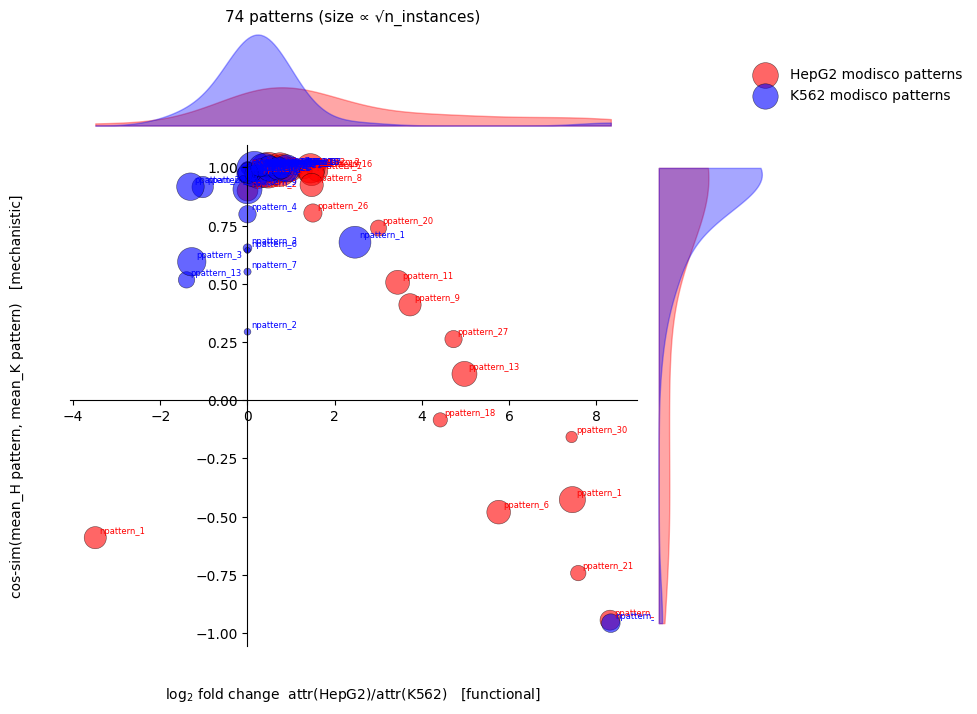

In [37]:
## Per-motif (functional, mechanistic) space — one point per pattern, with KDE marginals.
##   Average H and K attribution windows across all instances of the motif (untrimmed).
##     x = log2 fold change: log2(sum(mean_H) / sum(mean_K))    [functional]
##     y = cos-sim(mean_H_pattern, mean_K_pattern)              [mechanistic]
from scipy.stats import gaussian_kde
peak_starts = df['start_hg38'].fillna(0).astype(int).values
EPS = 1e-3

rows = []
for src_ct in CT:
    h = pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{src_ct}/hits.tsv'),
                    sep='\t', usecols=['start_untrimmed','end_untrimmed','motif_name','peak_id'])
    h['x0'] = h['start_untrimmed'].astype(int) - peak_starts[h['peak_id'].values]
    h['x1'] = h['end_untrimmed'  ].astype(int) - peak_starts[h['peak_id'].values]
    for motif, g in h.groupby('motif_name'):
        ig = g[(g['x0'] >= 0) & (g['x1'] <= ENH)]
        if len(ig) == 0: continue
        H_stack = np.stack([em.attr['HepG2'][int(r['peak_id']), :, int(r['x0']):int(r['x1'])]
                            for _, r in ig.iterrows()])
        K_stack = np.stack([em.attr['K562' ][int(r['peak_id']), :, int(r['x0']):int(r['x1'])]
                            for _, r in ig.iterrows()])
        mean_H = H_stack.mean(axis=0); mean_K = K_stack.mean(axis=0)
        nH, nK = np.linalg.norm(mean_H), np.linalg.norm(mean_K)
        css = float((mean_H * mean_K).sum() / (nH * nK)) if nH > 0 and nK > 0 else np.nan
        lfc = np.log2(max(mean_H.sum(), EPS) / max(mean_K.sum(), EPS))
        rows.append(dict(src_ct=src_ct, motif=motif, n=len(ig), lfc=lfc, cossim=css))
M = pd.DataFrame(rows)

fig = plt.figure(figsize=(9, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                      wspace=0.05, hspace=0.05)
ax     = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

for src_ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = M[M['src_ct'] == src_ct]
    ax.scatter(sub['lfc'], sub['cossim'], s=np.sqrt(sub['n']) * 4,
               c=color, alpha=0.6, edgecolors='k', lw=0.4,
               label=f'{src_ct} modisco patterns')
    for _, r in sub.iterrows():
        short = r['motif'].replace('pos_patterns.', 'p').replace('neg_patterns.', 'n')
        ax.annotate(short, (r['lfc'], r['cossim']), fontsize=6,
                    xytext=(3, 3), textcoords='offset points', color=color)

# KDE marginals (one curve per ct)
for src_ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = M[M['src_ct'] == src_ct]
    x = sub['lfc'].dropna().values
    y = sub['cossim'].dropna().values
    if len(x) > 1:
        xs = np.linspace(M['lfc'].min(), M['lfc'].max(), 200)
        ax_top.fill_between(xs, gaussian_kde(x)(xs), color=color, alpha=0.35)
    if len(y) > 1:
        ys = np.linspace(M['cossim'].min(), M['cossim'].max(), 200)
        ax_rgt.fill_betweenx(ys, gaussian_kde(y)(ys), color=color, alpha=0.35)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
ax.set_xlabel('log$_2$ fold change  attr(HepG2)/attr(K562)   [functional]')
ax.set_ylabel('cos-sim(mean_H pattern, mean_K pattern)   [mechanistic]')
ax.xaxis.set_label_coords(0.5, -0.08); ax.yaxis.set_label_coords(-0.08, 0.5)

for a in (ax_top, ax_rgt):
    a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for sp in a.spines.values(): sp.set_visible(False)

ax_top.set_title(f'{len(M)} patterns (size ∝ √n_instances)', fontsize=11)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.18, 1.18))
plt.show()


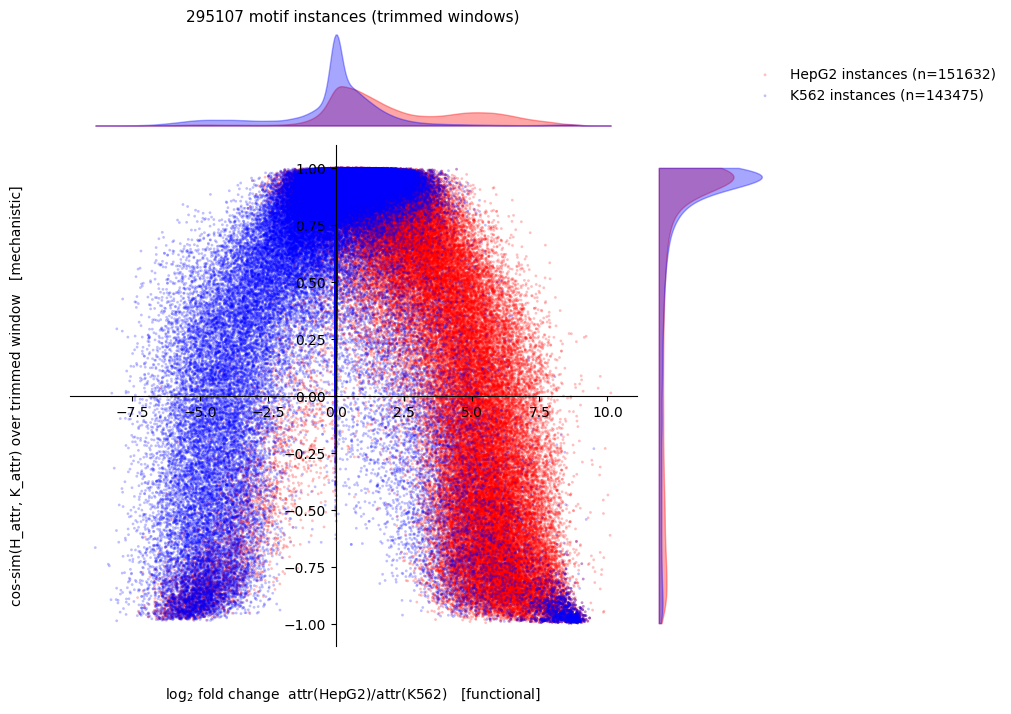

In [36]:
## Same (functional, mechanistic) space but one dot per motif INSTANCE, with KDE marginals.
##   Trimmed instance windows ([start, end] from finemo, default cwm-trim 0.3).
##     x = log2 fold change: log2(sum(H_attr) / sum(K_attr))   [functional]
##     y = cos-sim(H_attr, K_attr) over trimmed window         [mechanistic]
from scipy.stats import gaussian_kde
peak_starts = df['start_hg38'].fillna(0).astype(int).values
EPS = 1e-3

inst = []
for src_ct in CT:
    h = pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{src_ct}/hits.tsv'),
                    sep='\t', usecols=['start','end','motif_name','peak_id'])
    h['x0'] = h['start'].astype(int) - peak_starts[h['peak_id'].values]
    h['x1'] = h['end'  ].astype(int) - peak_starts[h['peak_id'].values]
    h = h[(h['x0'] >= 0) & (h['x1'] <= ENH)].reset_index(drop=True)
    H_sums, K_sums, css = [], [], []
    for _, hit in h.iterrows():
        pid, x0, x1 = int(hit['peak_id']), int(hit['x0']), int(hit['x1'])
        H = em.attr['HepG2'][pid, :, x0:x1]; K = em.attr['K562'][pid, :, x0:x1]
        H_sums.append(H.sum()); K_sums.append(K.sum())
        Hf, Kf = H.ravel(), K.ravel()
        nH, nK = np.linalg.norm(Hf), np.linalg.norm(Kf)
        css.append(float((Hf * Kf).sum() / (nH * nK)) if nH > 0 and nK > 0 else np.nan)
    H_sums = np.array(H_sums); K_sums = np.array(K_sums)
    h['lfc']    = np.log2(np.maximum(H_sums, EPS) / np.maximum(K_sums, EPS))
    h['cossim'] = css
    h['src_ct'] = src_ct
    inst.append(h)
I = pd.concat(inst, ignore_index=True)

fig = plt.figure(figsize=(9, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                      wspace=0.05, hspace=0.05)
ax     = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

for src_ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = I[I['src_ct'] == src_ct]
    ax.scatter(sub['lfc'], sub['cossim'], s=4, c=color, alpha=0.25,
               edgecolors='none', rasterized=True, label=f'{src_ct} instances (n={len(sub)})')

xs = np.linspace(I['lfc'].min(), I['lfc'].max(), 400)
ys = np.linspace(I['cossim'].min(), I['cossim'].max(), 400)
for src_ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = I[I['src_ct'] == src_ct]
    x = sub['lfc'].dropna().values
    y = sub['cossim'].dropna().values
    if len(x) > 1: ax_top.fill_between(xs, gaussian_kde(x)(xs), color=color, alpha=0.35)
    if len(y) > 1: ax_rgt.fill_betweenx(ys, gaussian_kde(y)(ys), color=color, alpha=0.35)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
ax.set_xlabel('log$_2$ fold change  attr(HepG2)/attr(K562)   [functional]')
ax.set_ylabel('cos-sim(H_attr, K_attr) over trimmed window   [mechanistic]')
ax.xaxis.set_label_coords(0.5, -0.08); ax.yaxis.set_label_coords(-0.08, 0.5)

for a in (ax_top, ax_rgt):
    a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for sp in a.spines.values(): sp.set_visible(False)

ax_top.set_title(f'{len(I)} motif instances (trimmed windows)', fontsize=11)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.18, 1.18))
plt.show()


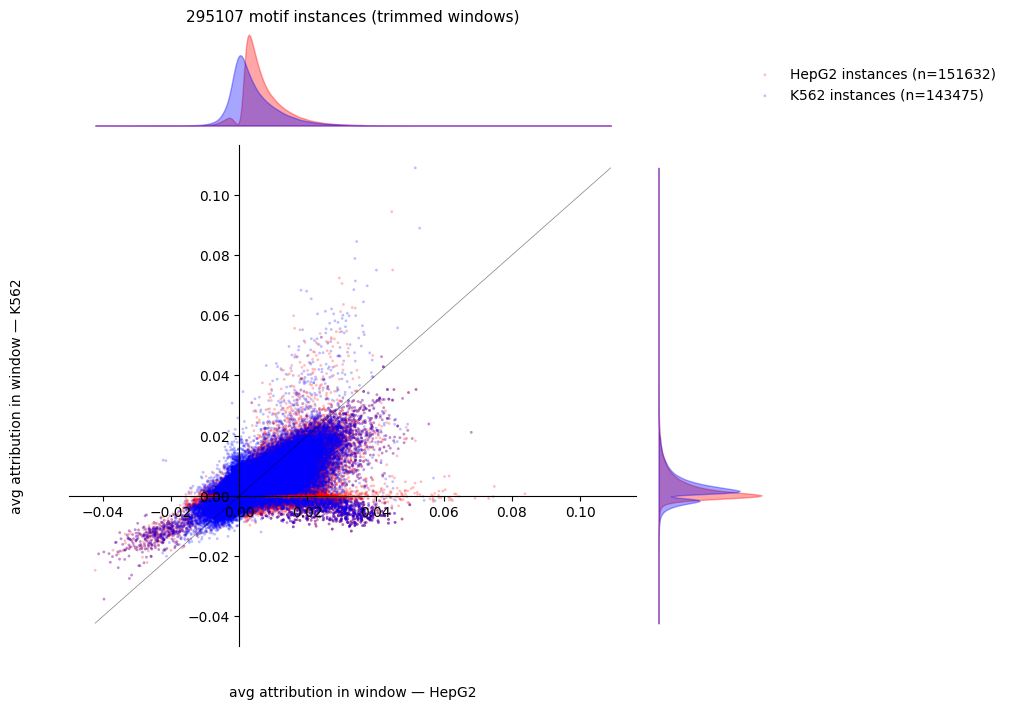

In [38]:
## Per-instance HepG2 vs K562 average attribution within the trimmed window.
##   x = mean(H_attr in window)   y = mean(K_attr in window)   one dot per instance.
peak_starts = df['start_hg38'].fillna(0).astype(int).values

inst = []
for src_ct in CT:
    h = pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{src_ct}/hits.tsv'),
                    sep='\t', usecols=['start','end','motif_name','peak_id'])
    h['x0'] = h['start'].astype(int) - peak_starts[h['peak_id'].values]
    h['x1'] = h['end'  ].astype(int) - peak_starts[h['peak_id'].values]
    h = h[(h['x0'] >= 0) & (h['x1'] <= ENH)].reset_index(drop=True)
    H_avg, K_avg = [], []
    for _, hit in h.iterrows():
        pid, x0, x1 = int(hit['peak_id']), int(hit['x0']), int(hit['x1'])
        H_avg.append(em.attr['HepG2'][pid, :, x0:x1].sum() / (x1 - x0))
        K_avg.append(em.attr['K562' ][pid, :, x0:x1].sum() / (x1 - x0))
    h['H_avg'] = H_avg; h['K_avg'] = K_avg
    h['src_ct'] = src_ct
    inst.append(h)
I = pd.concat(inst, ignore_index=True)

fig = plt.figure(figsize=(9, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                      wspace=0.05, hspace=0.05)
ax     = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

for src_ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = I[I['src_ct'] == src_ct]
    ax.scatter(sub['H_avg'], sub['K_avg'], s=4, c=color, alpha=0.25,
               edgecolors='none', rasterized=True, label=f'{src_ct} instances (n={len(sub)})')

lo, hi = I[['H_avg','K_avg']].min().min(), I[['H_avg','K_avg']].max().max()
ax.plot([lo, hi], [lo, hi], 'k-', lw=0.5, alpha=0.5)

xs = np.linspace(lo, hi, 400)
for src_ct, color in zip(['HepG2', 'K562'], ['red', 'blue']):
    sub = I[I['src_ct'] == src_ct]
    if len(sub) > 1:
        ax_top.fill_between(xs, gaussian_kde(sub['H_avg'].values)(xs), color=color, alpha=0.35)
        ax_rgt.fill_betweenx(xs, gaussian_kde(sub['K_avg'].values)(xs), color=color, alpha=0.35)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
ax.set_xlabel('avg attribution in window — HepG2')
ax.set_ylabel('avg attribution in window — K562')
ax.xaxis.set_label_coords(0.5, -0.08); ax.yaxis.set_label_coords(-0.08, 0.5)

for a in (ax_top, ax_rgt):
    a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for sp in a.spines.values(): sp.set_visible(False)

ax_top.set_title(f'{len(I)} motif instances (trimmed windows)', fontsize=11)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.18, 1.18))
plt.show()
